# Executive Summary

This notebook presents an Exploratory Data Analysis (EDA) of the cleaned sales dataset prepared during Task 1 of the ApexPlanet Data Analytics Internship.

The analysis focuses on understanding sales performance, customer demographics, product demand, geographic distribution, and revenue trends. It also identifies key business insights through statistical analysis and visualization.

The findings from this notebook serve as the foundation for Business Intelligence reporting and dashboard development in subsequent tasks.

# Exploratory Data Analysis (EDA)

## ApexPlanet Data Analytics Internship

### Task 2: Exploratory Data Analysis & Business Intelligence

### Objective

The objective of this notebook is to explore the cleaned sales dataset, identify patterns, analyze business performance, generate key performance indicators (KPIs), and derive actionable insights through visualization and statistical analysis.

### Dataset

- Source: Cleaned Sales Dataset
- Records: 1000
- Features: 13 (including Age_Group)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

%matplotlib inline

In [2]:
df = pd.read_csv("../data/processed/cleaned_dataset.csv")

print(df.shape)

df.head()

(1000, 13)


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales,Age_Group
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39,Young
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80,Senior
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48,Senior
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24,Senior
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90,Adult


In [3]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Age"] = df["Age"].astype(int)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   object        
 1   Order_Date     1000 non-null   datetime64[ns]
 2   Customer_ID    1000 non-null   object        
 3   Customer_Name  1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   Gender         1000 non-null   object        
 6   City           1000 non-null   object        
 7   Product        1000 non-null   object        
 8   Category       1000 non-null   object        
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
 12  Age_Group      1000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(8)
memory usage: 101.7+ KB


In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_Date,1000,2025-07-03 11:19:40.800000,2025-01-01 00:00:00,2025-03-30 18:00:00,2025-07-01 00:00:00,2025-10-07 06:00:00,2026-01-01 00:00:00,NaN
Age,1000.0,41.353,18.0,30.0,41.0,53.0,65.0,13.683626
Quantity,1000.0,5.435,1.0,3.0,5.0,8.0,10.0,2.838632
Unit_Price,1000.0,25486.78341,145.78,13895.7225,25398.74,37512.3825,49997.53,14179.402361
Total_Sales,1000.0,139399.43965,437.34,47066.6325,108594.025,203722.8825,493677.5,114100.051546


In [6]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
Age_Group        0
dtype: int64

### Observation

The cleaned dataset contains no missing values and is ready for exploratory analysis.

# Business Questions

This analysis aims to answer the following business questions:

1. What is the overall business performance?
2. Which products generate the highest revenue?
3. Which product categories contribute the most sales?
4. Which cities generate the highest revenue?
5. Which customer segment spends the most?
6. What are the monthly sales trends?
7. Are there any relationships between numerical variables?

# Key Performance Indicators (KPIs)

KPIs provide a quick overview of the business performance.

In [7]:
total_revenue = df["Total_Sales"].sum()

total_orders = df["Order_ID"].nunique()

total_customers = df["Customer_ID"].nunique()

avg_order_value = total_revenue / total_orders

avg_customer_value = total_revenue / total_customers

print(f"Total Revenue      : ₹{total_revenue:,.2f}")
print(f"Total Orders       : {total_orders}")
print(f"Total Customers    : {total_customers}")
print(f"Average Order Value: ₹{avg_order_value:,.2f}")
print(f"Revenue/Customer   : ₹{avg_customer_value:,.2f}")

Total Revenue      : ₹139,399,439.65
Total Orders       : 992
Total Customers    : 947
Average Order Value: ₹140,523.63
Revenue/Customer   : ₹147,201.10


## Univariate Analysis

### Age Distribution

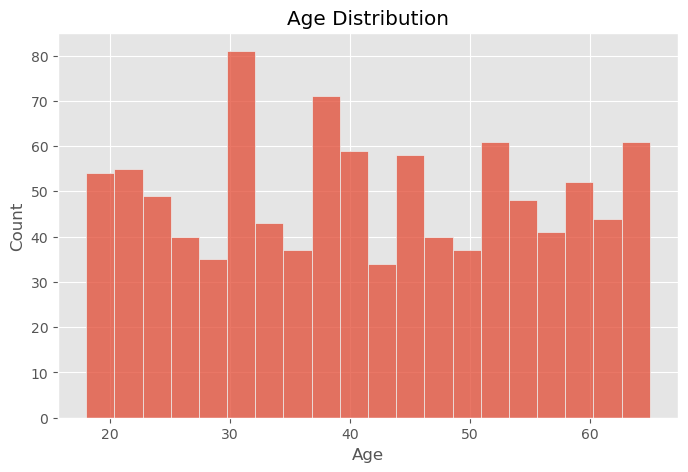

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.show()

Most customers fall within the adult age range, indicating that the primary customer base consists of working-age individuals.

### Gender Distribution

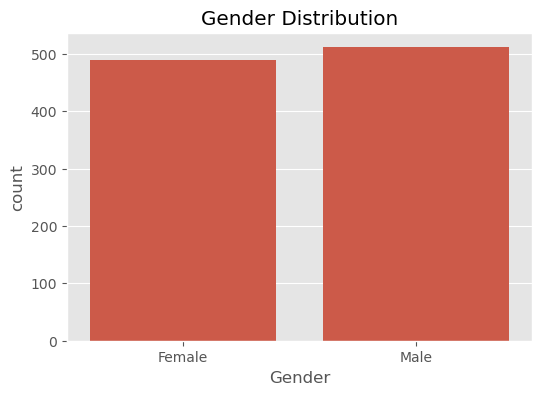

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")

plt.show()

### Category Distribution

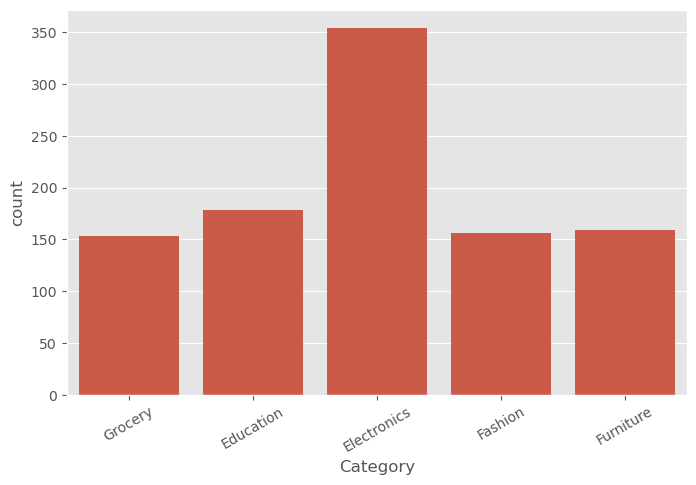

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(x="Category", data=df)

plt.xticks(rotation=30)

plt.show()

## Product Analysis

In [11]:
product_sales = (
    df.groupby("Product")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

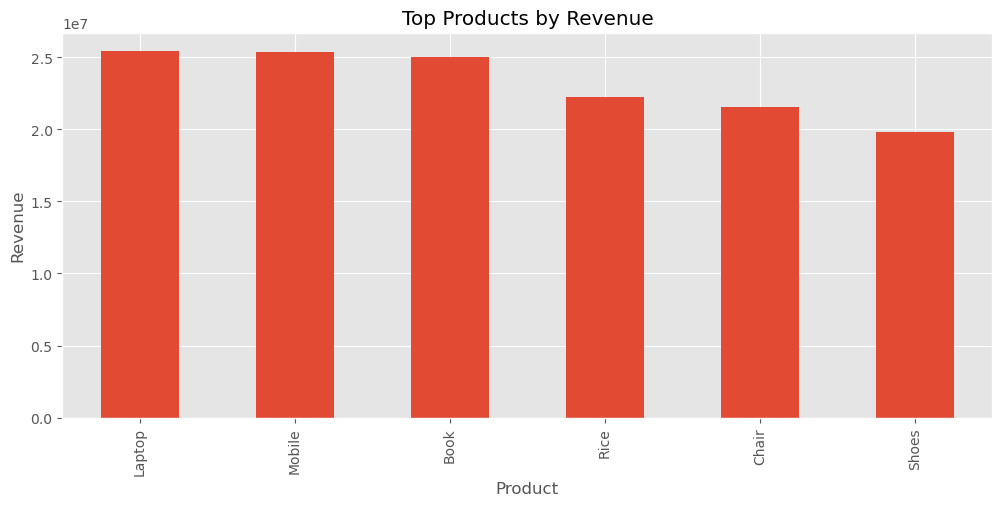

In [12]:
plt.figure(figsize=(12,5))

product_sales.plot(kind="bar")

plt.title("Top Products by Revenue")

plt.ylabel("Revenue")

plt.show()

The top-performing products contribute a significant share of total revenue and should be prioritized in inventory planning and promotional campaigns.

## Category Analysis

In [13]:
category_sales = (
    df.groupby("Category")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

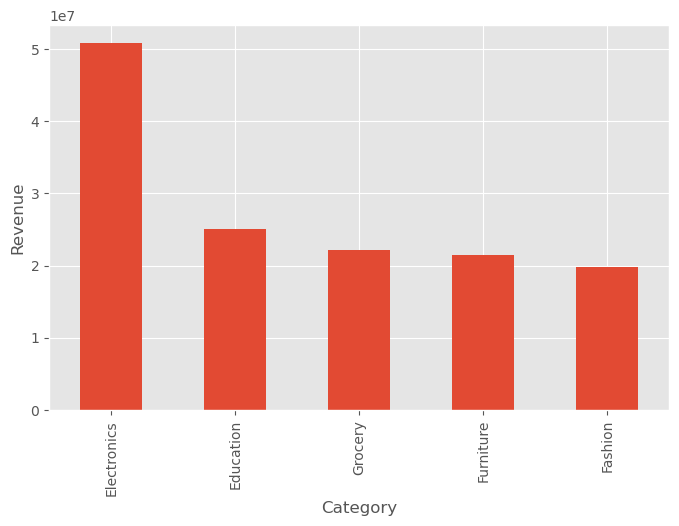

In [14]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.ylabel("Revenue")

plt.show()

The highest revenue-generating category represents the strongest business segment and should receive focused investment.

## City Analysis

In [15]:
city_sales = (
    df.groupby("City")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
)

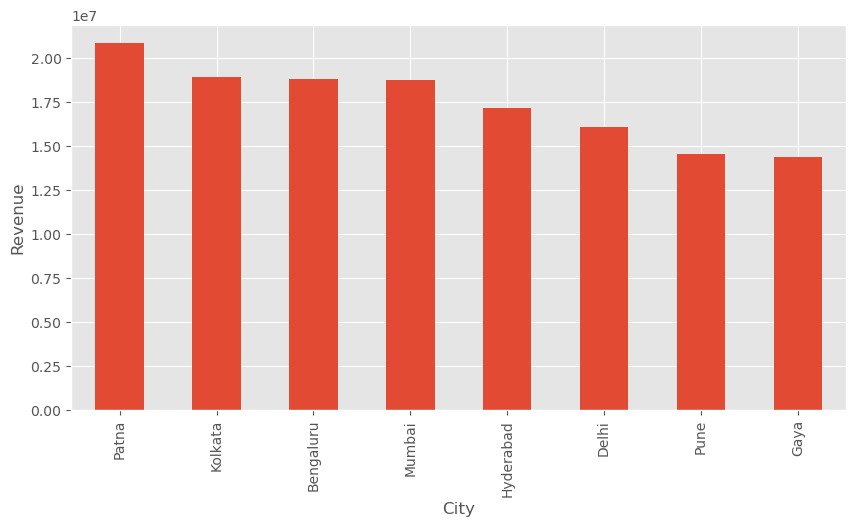

In [16]:
plt.figure(figsize=(10,5))

city_sales.plot(kind="bar")

plt.ylabel("Revenue")

plt.show()

Top-performing cities indicate regions with higher customer demand and greater market potential.

## Customer Segmentation

### Age Group

In [17]:
age_sales = (
    df.groupby("Age_Group")["Total_Sales"]
    .sum()
)

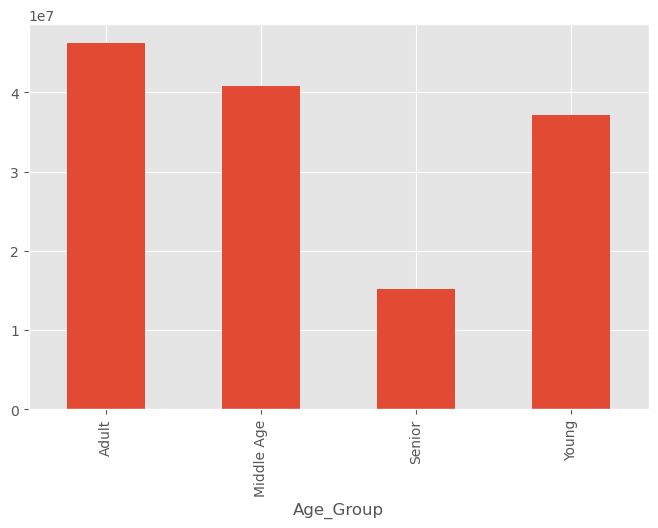

In [18]:
plt.figure(figsize=(8,5))

age_sales.plot(kind="bar")

plt.show()

### Gender Revenue

In [19]:
gender_sales = (
    df.groupby("Gender")["Total_Sales"]
    .sum()
)

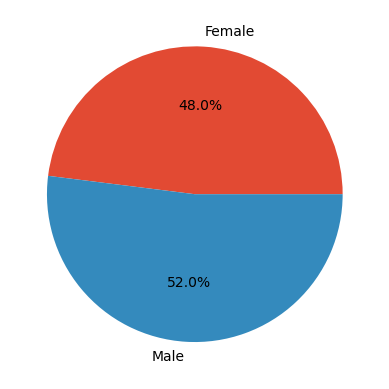

In [20]:
gender_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.show()

Customer segmentation enables targeted marketing strategies for different demographic groups.

## Time-Series Analysis

In [21]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"] = df["Order_Date"].dt.to_period("M")

In [22]:
monthly_sales = (
    df.groupby("Month")["Total_Sales"]
    .sum()
)

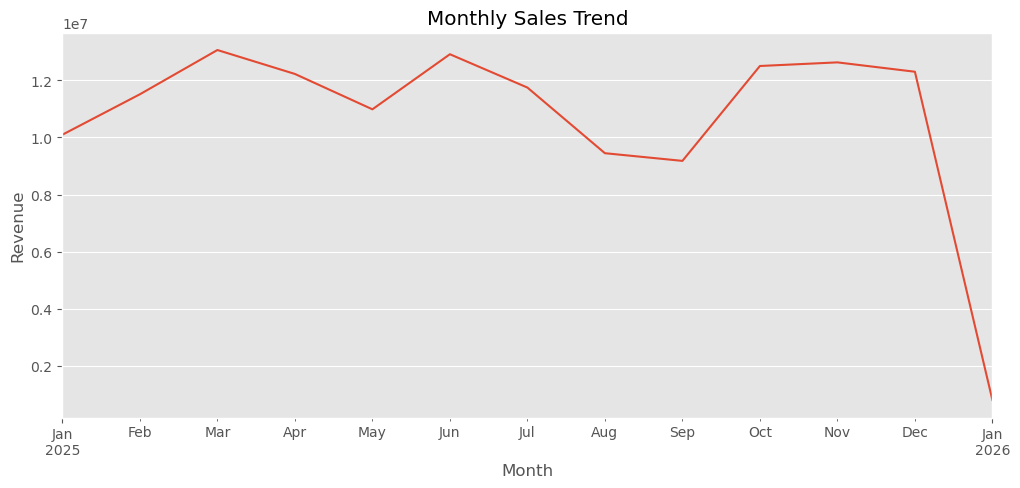

In [23]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.ylabel("Revenue")

plt.show()

Monthly sales trends help identify seasonality, demand fluctuations, and growth opportunities.

## Correlation Analysis

In [24]:
corr = df[
    [
        "Age",
        "Quantity",
        "Unit_Price",
        "Total_Sales"
    ]
].corr()

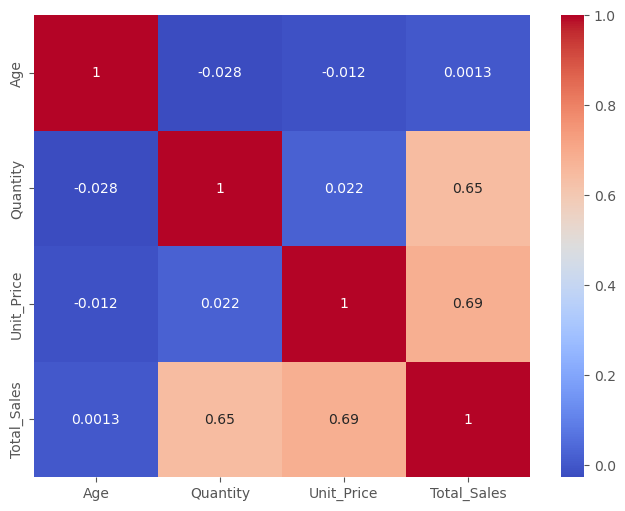

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

Correlation analysis reveals relationships among numerical variables and supports future predictive modeling.

## Top Customers

In [26]:
top_customers = (
    df.groupby("Customer_Name")["Total_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer_Name
Customer_335    1684832.52
Customer_138    1305932.64
Customer_266    1269445.22
Customer_375    1196934.33
Customer_274    1060340.15
Customer_343    1025447.16
Customer_415     967962.17
Customer_355     954513.58
Customer_1       952753.99
Customer_359     941957.21
Name: Total_Sales, dtype: float64

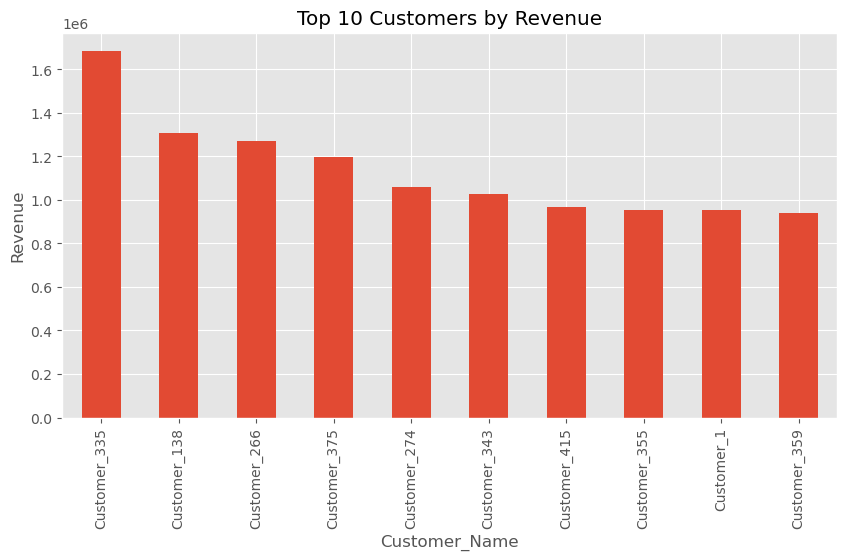

In [27]:
plt.figure(figsize=(10,5))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")

plt.ylabel("Revenue")

plt.show()

# Key Business Insights

- Highest revenue-generating products identified.
- Strongest-performing product categories analyzed.
- Top-performing cities recognized.
- Customer spending patterns segmented by age and gender.
- Monthly sales trends evaluated.
- Correlation among numerical features examined.

These findings provide a strong foundation for business intelligence reporting and dashboard development.

# Conclusion

The exploratory analysis identified key trends in customer behavior, product performance, category contribution, geographic sales distribution, and monthly revenue patterns.

Key outcomes include:

- Identification of the highest-performing products and categories
- Recognition of top revenue-generating cities
- Customer segmentation through Age_Group analysis
- Validation of sales trends over time
- Exploration of relationships among numerical variables

The insights generated in this notebook provide a strong foundation for Business Intelligence reporting, SQL-based analysis, and interactive dashboard development in the next phase of the project.